In [1]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageStat
import torch
import hashlib
import io
import imagehash
import json

In [2]:
DATASET_DIR = Path("data/raw-img")
SPLIT_DIR = Path("data/split")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cpu


# Dataset Exploration


In [3]:
classes = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
class_counts = {cls: len(list((DATASET_DIR / cls).iterdir())) for cls in classes}

print("Classes:", classes)
print("Num classes:", len(classes))
print(class_counts)

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Num classes: 10
{'cane': 4863, 'cavallo': 2618, 'elefante': 1446, 'farfalla': 2110, 'gallina': 3096, 'gatto': 1662, 'mucca': 1862, 'pecora': 1818, 'ragno': 4818, 'scoiattolo': 1861}


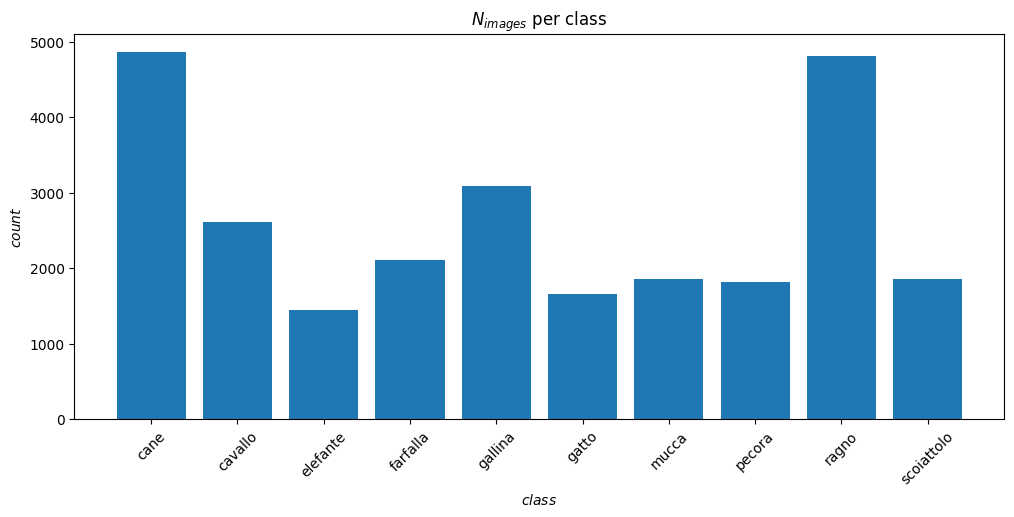

In [4]:
plt.figure(figsize=(12,5))
plt.bar(list(class_counts.keys()), list(class_counts.values()))
plt.xticks(rotation=45)
plt.title(r"$N_{images}$ per class")
plt.xlabel(r"$class$")
plt.ylabel(r"$count$")
plt.show()

# Exact Duplicate Detection

In [5]:
for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    hashes = set()
    duplicate_found = False

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hashes:
            duplicate_found = True
            break

        hashes.add(file_hash)

    print(cls_dir.name, duplicate_found)

cane False
cavallo False
elefante False
farfalla False
gallina False
gatto False
mucca False
pecora False
ragno False
scoiattolo False


# Normalized Duplicate Detection

In [6]:
TARGET_SIZE = (128,128)
hash_to_files = defaultdict(list)

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB").resize(TARGET_SIZE)
            buf = io.BytesIO()
            img.save(buf, format="PNG")
            h = hashlib.md5(buf.getvalue()).hexdigest()
            hash_to_files[h].append(img_path)
        except:
            pass

duplicates = {h:files for h,files in hash_to_files.items() if len(files)>1}
print(len(duplicates))

0


# Perceptual Similarity Detection

In [7]:
TARGET_SIZE = (128,128)

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    hashes = {}
    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB").resize(TARGET_SIZE)
            buf = io.BytesIO()
            img.save(buf, format="PNG")
            h = hashlib.md5(buf.getvalue()).hexdigest()

            if h in hashes:
                img_path.unlink()
            else:
                hashes[h] = img_path
        except:
            pass

# Corrupted Image Filtering

In [8]:
deleted = 0

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            img_path.unlink()
            deleted += 1

print(deleted)

0


# Small Image Filtering

In [9]:
deleted = []
MIN_SIZE = 100

for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path)
            if img.width < MIN_SIZE or img.height < MIN_SIZE:
                deleted.append(str(img_path))
                img_path.unlink()
        except:
            pass

print(len(deleted))

0


# Aspect Ratio Filtering

In [10]:
for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    weird = []

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path)
            ratio = img.width / img.height

            if ratio > 3 or ratio < 0.3:
                weird.append((img_path.name, ratio))
        except:
            pass

    print(cls_dir.name, len(weird))

cane 0
cavallo 0
elefante 0
farfalla 0
gallina 0
gatto 0
mucca 0
pecora 0
ragno 0
scoiattolo 0


# Low Information Filtering

In [11]:
for cls_dir in DATASET_DIR.iterdir():
    if not cls_dir.is_dir():
        continue

    removed = 0

    for img_path in cls_dir.iterdir():
        if not img_path.is_file():
            continue

        try:
            img = Image.open(img_path).convert("RGB").resize((128,128))
            stat = ImageStat.Stat(img)
            variance = sum(stat.var)/len(stat.var)

            if variance < 50:
                img_path.unlink()
                removed += 1
        except:
            pass

    print(cls_dir.name, removed)

cane 0
cavallo 0
elefante 0
farfalla 0
gallina 0
gatto 0
mucca 0
pecora 0
ragno 0
scoiattolo 0
